In [25]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import TargetEncoder
from concurrent.futures import ThreadPoolExecutor
import itertools
import gc
from lightgbm import LGBMClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import warnings
warnings.filterwarnings("ignore")

Now that the features are selected, we would need to reconstruct them using only the training partition.

Again, we use an unconventional naming scheme here: 
- training
- testing
- out-of-time validation set

We unfortunately only have a full year of data. Ideally, we would want to have at least one year of data in the training + testing partition to account for seasonality. However, given the circumstance, we would have to compromise on this and leave some of the months for real out-of-time validation set for true out-of-sample testing that is realistic in a real-time fraud detection algorithm.

We leave the validation set out for real out-of-time prediction, and for the rest, we apply a k-fold cross validation.

### Data Prep

In [26]:
df = pd.read_parquet('data/cleaned_card_transactions_with_entities.parquet')
df.Date.min(), df.Date.max()

(Timestamp('2010-01-01 00:00:00'), Timestamp('2010-12-31 00:00:00'))

In [27]:
df.columns

Index(['Recnum', 'Cardnum', 'Date', 'Merchnum', 'Merch description',
       'Merch state', 'Merch zip', 'Amount', 'Fraud', 'amount_okay',
       'DayOfWeek', 'card_merch', 'card_zip', 'card_state', 'card_merchdesc',
       'card_dow', 'merch_zip', 'merch_state', 'merchnum_desc', 'merchnum_dow',
       'state_desc', 'merchdesc_dow', 'merchdesc_state', 'merchdesc_zip',
       'card_merchnum_desc', 'card_merchnum_zip', 'card_merchnum_state',
       'card_merchdesc_zip', 'card_merchdesc_state', 'merchnum_desc_state',
       'merchnum_desc_zip', 'zip3', 'card_zip3', 'state_zip', 'merchnum_zip3'],
      dtype='object')

In [28]:
df_oot = df[df.Date >= '2010-11-01']
df_train_test = df[df.Date < '2010-11-01']

In [29]:
selected_features = pd.read_csv('data/selected_features_ks.csv')
TOP_NVAR = 18
selected_features = selected_features['feature'].tolist()[:TOP_NVAR]

In [30]:
selected_features

['Cardnum_vdratio_1by14',
 'card_merchdesc_zip_total_14',
 'Cardnum_unique_count_for_card_state_3',
 'merch_zip_actual/med_60',
 'card_zip_unique_count_for_merchnum_dow_60',
 'Cardnum_count_1_by_7',
 'card_dow_unique_count_for_card_merchnum_zip_60',
 'card_state_variability_max_3',
 'merchnum_desc_state_actual/avg_60',
 'Cardnum_count_1_by_7_sq',
 'Cardnum_unique_count_for_card_dow_1',
 'card_dow_actual/med_7',
 'card_dow_actual/avg_7',
 'card_dow_actual/max_7',
 'card_dow_unique_count_for_merch_zip_60',
 'card_dow_unique_count_for_Merchnum_60',
 'card_dow_unique_count_for_merch_state_60',
 'card_dow_unique_count_for_card_merch_60']

The model building pipeline is delineated as follows:

1. Reconstruct only the selected features
2. Robust Scaler
3. Clip outliers
4. Standard Scaler
5. PCA (Optional)
6. Model building

All of this should be done on specifically the training partition, but evaluated on testing and validation.

### Exploratory Analysis for PCA

Before we do that, though, we should implement exploratory analysis and visualize variance as a function of number of components. And we do this globally, ignoring partition. 

In [32]:
from feature_engineering import construct_features

# For PCA exploration, use full historical data to construct features
X_train_test_full = construct_features(
    df_historical=df_train_test,
    df_current=df_train_test,  
    selected_features=selected_features,
    verbose=True
)

print(f"\nFeatures shape: {X_train_test_full.shape}")
print(f"Target shape: {df_train_test['Fraud'].shape}")
print(f"Fraud rate: {df_train_test['Fraud'].mean():.2%}")

Historical data: 85400 rows
Current data: 85400 rows
Selected features: 18

[1/3] Analyzing feature requirements...
  Entities needed: 12
  Time windows needed: [1, 3, 7, 14, 60]
  Base features: 10
  Derived features: 17
  Target encoding: 0
  Business features: 0

[3/3] Computing features...
  Computing time-based features for 5 entities...


  Time features: 100%|██████████| 5/5 [00:36<00:00,  7.30s/it]


  Computing variability features for 1 entities...


  Variability: 100%|██████████| 1/1 [00:01<00:00,  1.61s/it]


  Computing unique count features for 8 entity pairs...


  Unique counts: 100%|██████████| 8/8 [00:14<00:00,  1.84s/it]

  Computing 17 derived features...
Complete: 18 features constructed

Features shape: (85400, 18)
Target shape: (85400,)
Fraud rate: 2.50%


In [33]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

CLIP_THRESHOLD = 10

robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X_train_test_full)

X_clipped = np.clip(X_robust, -CLIP_THRESHOLD, CLIP_THRESHOLD)

standard_scaler = StandardScaler()
X_scaled = standard_scaler.fit_transform(X_clipped)

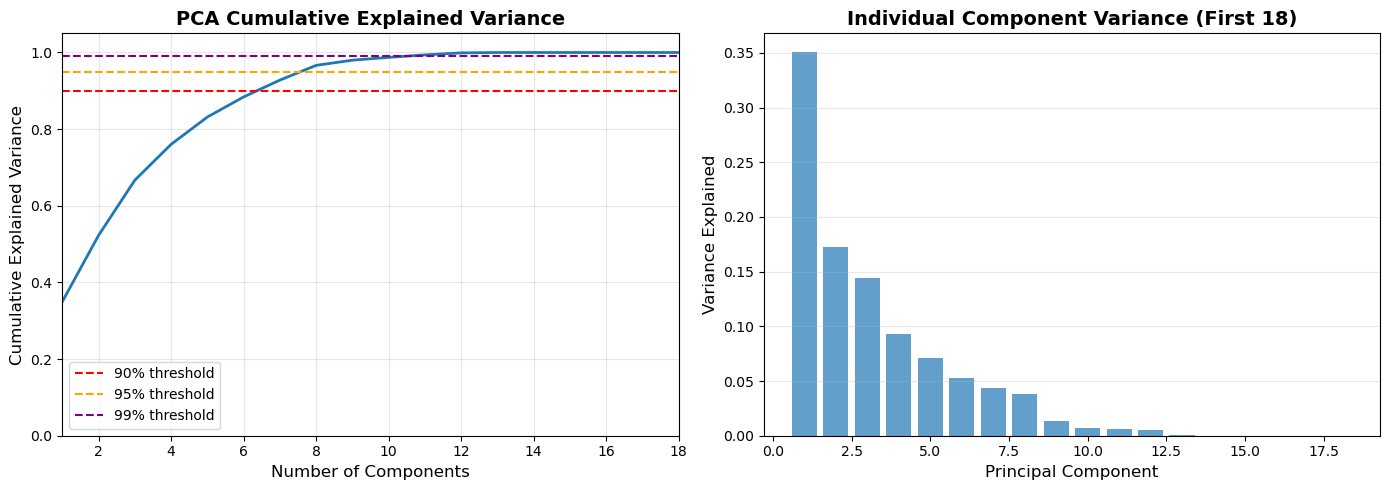

In [34]:
pca_full = PCA()
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
ax1.plot(range(1, len(cumsum_var) + 1), cumsum_var, linewidth=2)
ax1.axhline(y=0.90, color='r', linestyle='--', label='90% threshold', linewidth=1.5)
ax1.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold', linewidth=1.5)
ax1.axhline(y=0.99, color='purple', linestyle='--', label='99% threshold', linewidth=1.5)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax1.set_title('PCA Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(1, len(cumsum_var))
ax1.set_ylim(0, 1.05)

ax2 = axes[1]
n_bars = min(18, len(pca_full.explained_variance_ratio_))
ax2.bar(range(1, n_bars + 1), pca_full.explained_variance_ratio_[:n_bars], alpha=0.7)
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Variance Explained', fontsize=12)
ax2.set_title(f'Individual Component Variance (First {n_bars})', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Model Building